In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

/opt/anaconda3/envs/IRP/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv('../../../data/SCDs(Oake1).csv')

# defined wrong column names in excel
df = df.rename(columns={
    'Long': 'Lat',
    'Lat': 'Long'
})

SCDCENTRE1 = (51.02470839673911, -3.201945414712646)
SCDCENTRE2 = (51.026314416360776, -3.2030253527298393)

df = df.drop(columns=['Unnamed: 3'])

# ChatGPT assistanve with function
def haversine(lat1, lon1, lat2, lon2):
    """Distance between two lat/lon points in metres."""
    
    R = 6371000  # Earth radius, metres

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


d1 = haversine(
    df['Lat'],
    df['Long'],
    *SCDCENTRE1
)

d2 = haversine(
    df['Lat'],
    df['Long'],
    *SCDCENTRE2
)

df['Dist_to_nearest_centre'] = np.minimum(d1, d2)

In [17]:
df

,Lat,Long,Res,Dist_to_nearest_centre
0,51.025251,-3.201913,21,60.424281
1,51.025052,-3.201894,23,38.413820
2,51.024877,-3.201870,5,19.464473
3,51.024626,-3.201840,15,11.781480
4,51.024416,-3.201806,20,33.917734
5,51.025356,-3.201926,39,72.024836
6,51.025361,-3.202460,32,81.010398
7,51.025322,-3.203074,22,104.369518
8,51.025412,-3.203278,82,101.923495
9,51.025115,-3.203922,5,145.429958


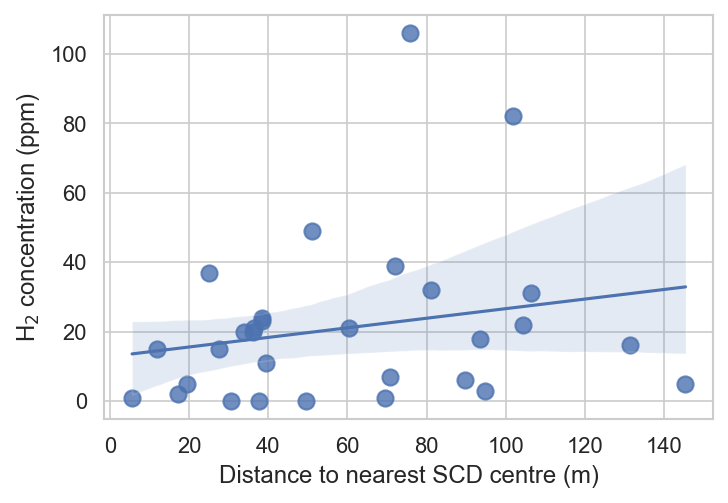

In [21]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=150)

sns.regplot(
    data=df,
    x="Dist_to_nearest_centre",
    y="Res",
    scatter_kws={"s": 60},
    line_kws={"linewidth": 1.5},
    ax=ax
)

ax.set_xlabel("Distance to nearest SCD centre (m)")
ax.set_ylabel("H$_2$ concentration (ppm)")

plt.tight_layout()
plt.show()

# not very telling!